# 🍔 Zomato Delivery AI — Dual-Prediction System
### *Beginner-Friendly Machine Learning (No Pipelines)*

---

## 🎯 What are we building?
When a customer places an order on Zomato, the operations team needs two answers:

1. **ETA AI (Regression):** *How many minutes will this order take?*  
   $ightarrow$ Answer is a **number** (e.g., `24.5 minutes`). We use **Linear Regression**.
2. **Late Delivery AI (Classification):** *Is this order going to be late (> 30 min)?*  
   $ightarrow$ Answer is a **Yes (1) / No (0)**. We use **Logistic Regression**.

---

## 📋 Our Clean Dataset (`zomato_cleaned.csv`)
We have **10 columns**:
- **5 Numeric Features:** `distance_km`, `Delivery_person_Age`, `Delivery_person_Ratings`, `Vehicle_condition`, `multiple_deliveries`
- **3 Text/Category Features:** `Road_traffic_density`, `Weather_conditions`, `Festival`
- **2 Target Columns:** `Time_taken_min` (for Regression), `late` (for Classification)


## 1. Import Basic Libraries
We only need standard libraries: `pandas` for tables, `matplotlib` for plots, and `sklearn` for models.


In [1]:
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline


## 2. Load the Dataset
Let's load `zomato_cleaned.csv` and inspect the first 5 orders.


In [2]:
df = pd.read_csv("zomato_cleaned.csv")
print(f"Total Orders: {len(df):,}")
print(f"Total Columns: {len(df.columns)}")
df.head()


Total Orders: 42,444
Total Columns: 10


,distance_km,Delivery_person_Age,Delivery_person_Ratings,Vehicle_condition,multiple_deliveries,Road_traffic_density,Weather_conditions,Festival,Time_taken_min,late
0,10.28,36.0,4.2,2,3.0,Jam,Fog,No,46,1
1,6.24,21.0,4.7,1,1.0,High,Stormy,No,23,0
2,13.79,23.0,4.7,1,1.0,Medium,Sandstorms,No,21,0
3,2.93,34.0,4.3,0,0.0,Low,Sandstorms,No,20,0
4,19.40,24.0,4.7,1,1.0,Jam,Fog,No,41,1


## 3. Quick Data Inspection
Let's see summary statistics and check if there are any missing values.


In [3]:
# Summary statistics for numbers
df.describe().round(2)


,distance_km,Delivery_person_Age,Delivery_person_Ratings,Vehicle_condition,multiple_deliveries,Time_taken_min,late
count,42444.00,42444.00,42444.00,42444.00,42444.00,42444.00,42444.00
mean,9.76,29.59,4.63,1.00,0.75,26.44,0.30
std,5.60,5.76,0.31,0.82,0.57,9.33,0.46
min,1.47,20.00,2.50,0.00,0.00,10.00,0.00
25%,4.66,25.00,4.50,0.00,0.00,19.00,0.00
50%,9.22,30.00,4.70,1.00,1.00,26.00,0.00
75%,13.68,35.00,4.90,2.00,1.00,33.00,1.00
max,20.97,39.00,5.00,2.00,3.00,54.00,1.00


In [4]:
# Check for missing values (Blanks)
df.isna().sum()


distance_km                0
Delivery_person_Age        0
Delivery_person_Ratings    0
Vehicle_condition          0
multiple_deliveries        0
Road_traffic_density       0
Weather_conditions         0
Festival                   0
Time_taken_min             0
late                       0
dtype: int64

### 3.1 Histogram of Delivery Times
Most deliveries take between 15 and 35 minutes.


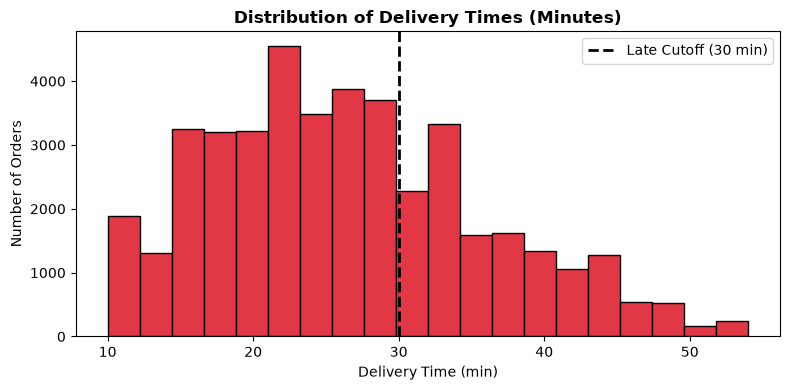

In [5]:
plt.figure(figsize=(8, 4))
plt.hist(df["Time_taken_min"], bins=20, color="#E23744", edgecolor="black")
plt.axvline(30, color="black", linestyle="--", linewidth=2, label="Late Cutoff (30 min)")
plt.title("Distribution of Delivery Times (Minutes)", fontweight="bold")
plt.xlabel("Delivery Time (min)")
plt.ylabel("Number of Orders")
plt.legend()
plt.tight_layout()
plt.show()


### 3.2 Impact of Traffic on Delivery Time


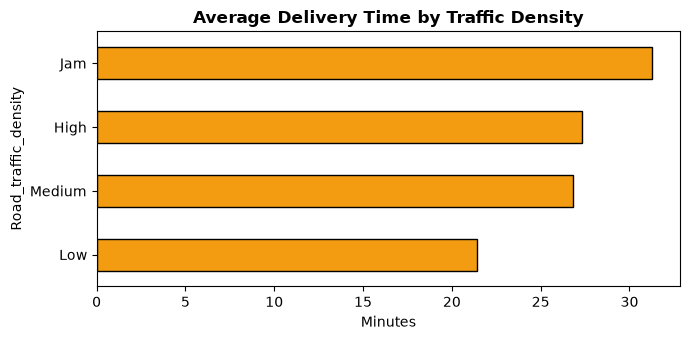

In [6]:
plt.figure(figsize=(7, 3.5))
df.groupby("Road_traffic_density")["Time_taken_min"].mean().sort_values().plot(
    kind="barh", color="#F39C12", edgecolor="black"
)
plt.title("Average Delivery Time by Traffic Density", fontweight="bold")
plt.xlabel("Minutes")
plt.tight_layout()
plt.show()


## 4. Simple Preprocessing: Text to Numbers (`pd.get_dummies`)
Machine learning equations cannot do math with words like `"Sunny"` or `"Jam"`.

We use **`pd.get_dummies()`** to turn text columns into clean **0 and 1 columns**:
- If `Road_traffic_density` was `"High"`, `Road_traffic_density_High` becomes `1`, others become `0`.


In [7]:
# Convert text columns into 0 and 1 columns
df = pd.get_dummies(df, columns=["Road_traffic_density", "Weather_conditions", "Festival"], dtype=int)
print(f"Number of columns after encoding: {len(df.columns)}")
df.head()


Number of columns after encoding: 19


,distance_km,Delivery_person_Age,Delivery_person_Ratings,Vehicle_condition,multiple_deliveries,Time_taken_min,late,Road_traffic_density_High,Road_traffic_density_Jam,Road_traffic_density_Low,Road_traffic_density_Medium,Weather_conditions_Cloudy,Weather_conditions_Fog,Weather_conditions_Sandstorms,Weather_conditions_Stormy,Weather_conditions_Sunny,Weather_conditions_Windy,Festival_No,Festival_Yes
0,10.28,36.0,4.2,2,3.0,46,1,0,1,0,0,0,1,0,0,0,0,1,0
1,6.24,21.0,4.7,1,1.0,23,0,1,0,0,0,0,0,0,1,0,0,1,0
2,13.79,23.0,4.7,1,1.0,21,0,0,0,0,1,0,0,1,0,0,0,1,0
3,2.93,34.0,4.3,0,0.0,20,0,0,0,1,0,0,0,1,0,0,0,1,0
4,19.40,24.0,4.7,1,1.0,41,1,0,1,0,0,0,1,0,0,0,0,1,0


## 5. Separate Inputs (X) and Outputs (y)
- **$X$ (Features):** All columns EXCEPT the answers (`Time_taken_min` and `late`).
- **$y_{\text{eta}}$:** Target for Linear Regression (minutes).
- **$y_{\text{late}}$:** Target for Logistic Regression (1 for late, 0 for on-time).


In [8]:
X = df.drop(columns=["Time_taken_min", "late"])
y_eta = df["Time_taken_min"]
y_late = df["late"]

feature_columns = list(X.columns)
print(f"Total input features for our models: {len(feature_columns)}")
print(feature_columns)


Total input features for our models: 17
['distance_km', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Vehicle_condition', 'multiple_deliveries', 'Road_traffic_density_High', 'Road_traffic_density_Jam', 'Road_traffic_density_Low', 'Road_traffic_density_Medium', 'Weather_conditions_Cloudy', 'Weather_conditions_Fog', 'Weather_conditions_Sandstorms', 'Weather_conditions_Stormy', 'Weather_conditions_Sunny', 'Weather_conditions_Windy', 'Festival_No', 'Festival_Yes']


## 6. Train / Test Split (80% / 20%)
Just like a student studies with practice problems and then takes an exam with new questions:
- **80% Training Data:** Used by the model to learn patterns.
- **20% Testing Data:** Kept hidden to fairly evaluate how good the model is.


In [9]:
X_train, X_test, y_eta_train, y_eta_test, y_late_train, y_late_test = train_test_split(
    X, y_eta, y_late, test_size=0.2, random_state=42
)

print(f"Training orders: {len(X_train):,}")
print(f"Testing orders : {len(X_test):,}")


Training orders: 33,955
Testing orders : 8,489


## 7. Model 1 — Linear Regression (ETA AI)
Linear Regression finds the best-fit line to predict delivery duration in minutes.


In [10]:
# 1. Create model
eta_model = LinearRegression()

# 2. Train on training data
eta_model.fit(X_train, y_eta_train)

# 3. Predict on test data
eta_predictions = eta_model.predict(X_test)


### 7.1 Evaluate Linear Regression (MAE)
**Mean Absolute Error (MAE):** Tells us how many minutes our prediction is off on average.


In [11]:
mae = mean_absolute_error(y_eta_test, eta_predictions)
print(f"Average Error (MAE): {mae:.2f} minutes")


Average Error (MAE): 4.81 minutes


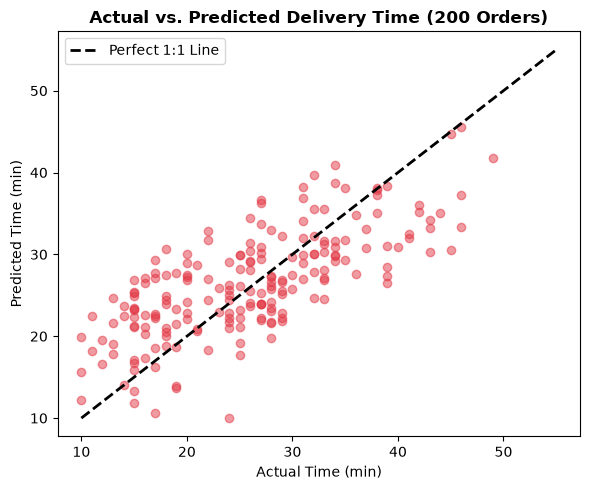

In [12]:
# Plot: Actual vs Predicted Delivery Time
plt.figure(figsize=(6, 5))
plt.scatter(y_eta_test[:200], eta_predictions[:200], alpha=0.5, color="#E23744")
plt.plot([10, 55], [10, 55], color="black", linestyle="--", linewidth=2, label="Perfect 1:1 Line")
plt.title("Actual vs. Predicted Delivery Time (200 Orders)", fontweight="bold")
plt.xlabel("Actual Time (min)")
plt.ylabel("Predicted Time (min)")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Model 2 — Logistic Regression (Late Delivery AI)
Logistic Regression predicts the **probability** of an event happening (in our case: Late = 1, On-Time = 0).


In [13]:
# 1. Create model
late_model = LogisticRegression(max_iter=1000)

# 2. Train on training data
late_model.fit(X_train, y_late_train)

# 3. Predict on test data
late_predictions = late_model.predict(X_test)


### 8.1 Evaluate Logistic Regression (Accuracy & Confusion Matrix)


In [14]:
acc = accuracy_score(y_late_test, late_predictions)
print(f"Accuracy: {acc * 100:.1f}%")


Accuracy: 88.3%


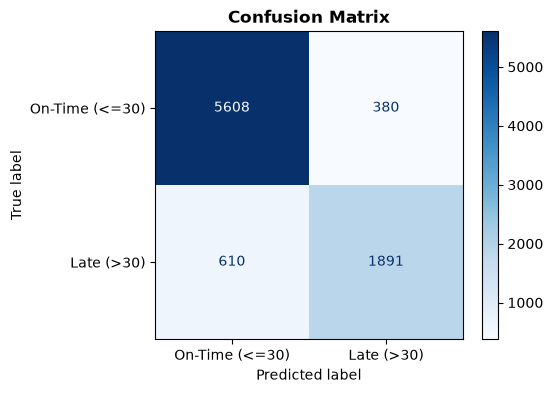

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_late_test, late_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["On-Time (<=30)", "Late (>30)"])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix", fontweight="bold")
plt.grid(False)
plt.show()


## 9. Live Test on a Sample Order
Let's test both models together on a simulated customer order:
- Distance: 6 km
- Driver Age: 25, Rating: 4.5
- Traffic: High
- Weather: Fog


In [16]:
sample_input = pd.DataFrame([{
    "distance_km": 6.0,
    "Delivery_person_Age": 25,
    "Delivery_person_Ratings": 4.5,
    "Vehicle_condition": 1,
    "multiple_deliveries": 1,
    "Road_traffic_density": "High",
    "Weather_conditions": "Fog",
    "Festival": "No"
}])

# One-hot encode and align columns with the training data
sample_encoded = pd.get_dummies(sample_input).reindex(columns=feature_columns, fill_value=0)

# Predict
predicted_minutes = eta_model.predict(sample_encoded)[0]
late_risk_probability = late_model.predict_proba(sample_encoded)[0, 1]

print("🍔 --- Order Delivery Prediction --- 🍔")
print(f"Estimated Time of Arrival (ETA) : {predicted_minutes:.1f} minutes")
print(f"Probability of being Late       : {late_risk_probability * 100:.1f}%")


🍔 --- Order Delivery Prediction --- 🍔
Estimated Time of Arrival (ETA) : 30.2 minutes
Probability of being Late       : 69.8%


## 10. Save Models for the Streamlit Web App
We save our trained models to disk using Python's built-in `pickle` module so our Streamlit app can load them.


In [17]:
os.makedirs("models", exist_ok=True)

with open("models/eta_linear_regression.pkl", "wb") as f:
    pickle.dump(eta_model, f)

with open("models/late_logistic_regression.pkl", "wb") as f:
    pickle.dump(late_model, f)

with open("models/model_info.pkl", "wb") as f:
    pickle.dump({"feature_cols": feature_columns, "late_threshold": 30}, f)

print("✅ Saved models to models/ folder successfully!")


✅ Saved models to models/ folder successfully!


## 11. Run the Interactive Web App
You can now run the Streamlit web application from your terminal:

```bash
streamlit run app.py
```
